<a href="https://colab.research.google.com/github/moanshori-repo/WaterQualityAssest/blob/main/Water_Quality_Assesment_using_Discriminant_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving WQD.xlsx to WQD.xlsx
User uploaded file "WQD.xlsx" with length 925902 bytes


In [2]:
import pandas as pd

df = pd.read_excel('WQD.xlsx')
display(df.head())

,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
0,67.448725,10.127148,0.208153,7.473607,10.181084,4.751657,218.364855,300.125080,337.178226,0.286054,4.355310,0.005984,0.066793,6069.624017,2
1,64.626666,94.015595,11.434463,10.859998,14.860521,3.085154,273.939692,8.426776,363.660740,0.096040,2.182753,0.004906,0.023428,250.995959,2
2,65.121842,90.653462,12.430865,12.809970,12.319980,9.648515,220.812730,11.726274,309.370934,0.974501,4.901760,0.006979,0.065041,7218.927473,2
3,1.640334,0.066344,10.963529,8.508023,12.955209,4.819988,266.571628,6.627655,8.180468,0.884865,3.571842,3.174473,0.026018,1230.062252,2
4,64.863434,2.119173,1.361736,13.335372,13.603197,10.244034,252.108000,339.891514,253.996871,0.801695,4.655898,3.854701,0.060995,1035.054820,2


In [3]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Temp,4300.0,25.695663,9.670202,0.194046,19.775926,25.041849,30.277718,84.251522
Turbidity (cm),4300.0,39.046681,20.942726,0.051424,22.224140,30.205696,55.945735,99.797743
DO(mg/L),4300.0,5.300346,1.832736,0.133928,3.978366,5.000754,6.521225,14.970122
BOD (mg/L),4300.0,3.125079,2.292060,1.000621,1.522077,2.236022,4.324578,14.943006
CO2,4300.0,6.375929,2.831104,0.001155,5.048761,6.598076,8.241532,14.984216
pH`,4300.0,7.713468,1.580282,0.003944,6.443019,7.743176,9.035251,14.851195
Alkalinity (mg L-1 ),4300.0,93.717183,68.949048,25.012328,40.422364,67.562607,132.834386,299.913160
Hardness (mg L-1 ),4300.0,127.055476,78.883091,0.255805,69.479620,111.063301,162.675648,398.796550
Calcium (mg L-1 ),4300.0,84.871932,75.718842,0.018293,23.745078,62.845419,115.596833,399.321398
Ammonia (mg L-1 ),4300.0,0.048269,0.122886,0.000001,0.012750,0.026335,0.039016,0.999300


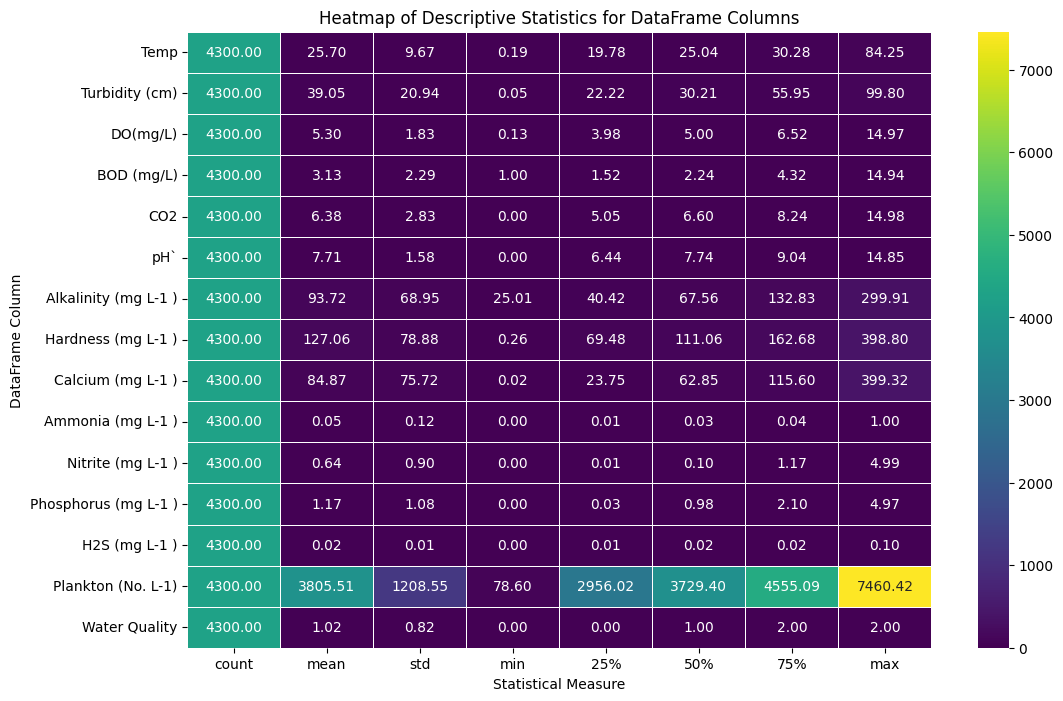

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get descriptive statistics and transpose for better visualization
df_desc = df.describe().T

# Create a heatmap of the descriptive statistics
plt.figure(figsize=(12, 8))
sns.heatmap(df_desc, annot=True, cmap='viridis', fmt='.2f', linewidths=.5)
plt.title('Heatmap of Descriptive Statistics for DataFrame Columns')
plt.xlabel('Statistical Measure')
plt.ylabel('DataFrame Column')
plt.show()

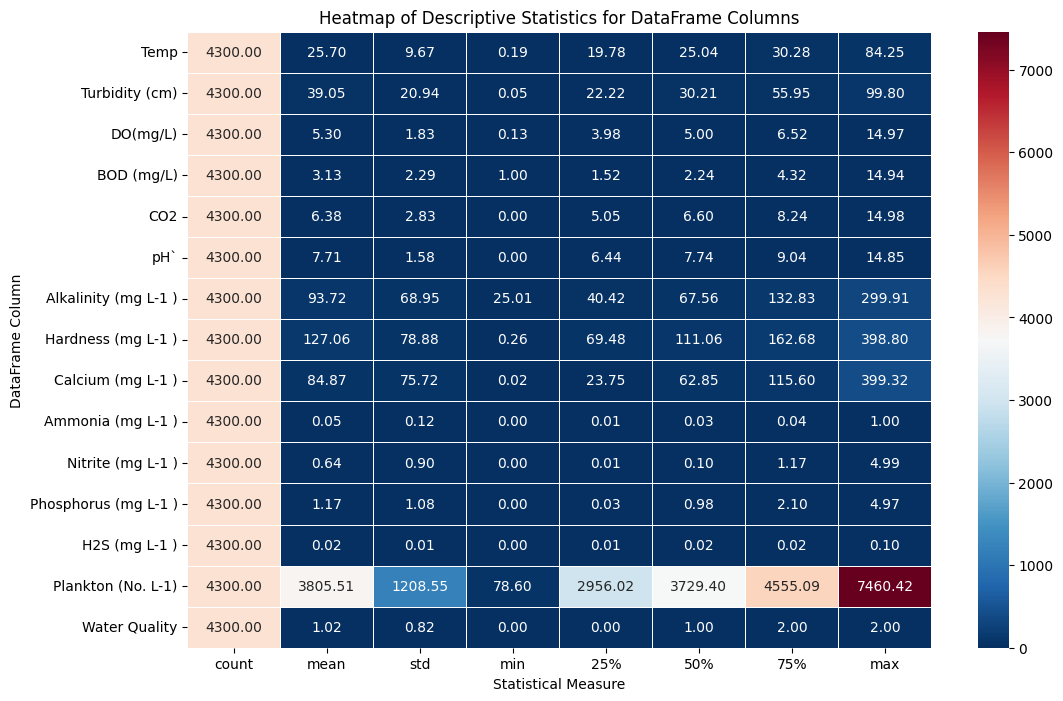

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get descriptive statistics and transpose for better visualization
df_desc = df.describe().T

# Create a heatmap of the descriptive statistics
plt.figure(figsize=(12, 8))
sns.heatmap(df_desc, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=.5)
plt.title('Heatmap of Descriptive Statistics for DataFrame Columns')
plt.xlabel('Statistical Measure')
plt.ylabel('DataFrame Column')
plt.show()

### Visualizing Outliers using Violin Plots

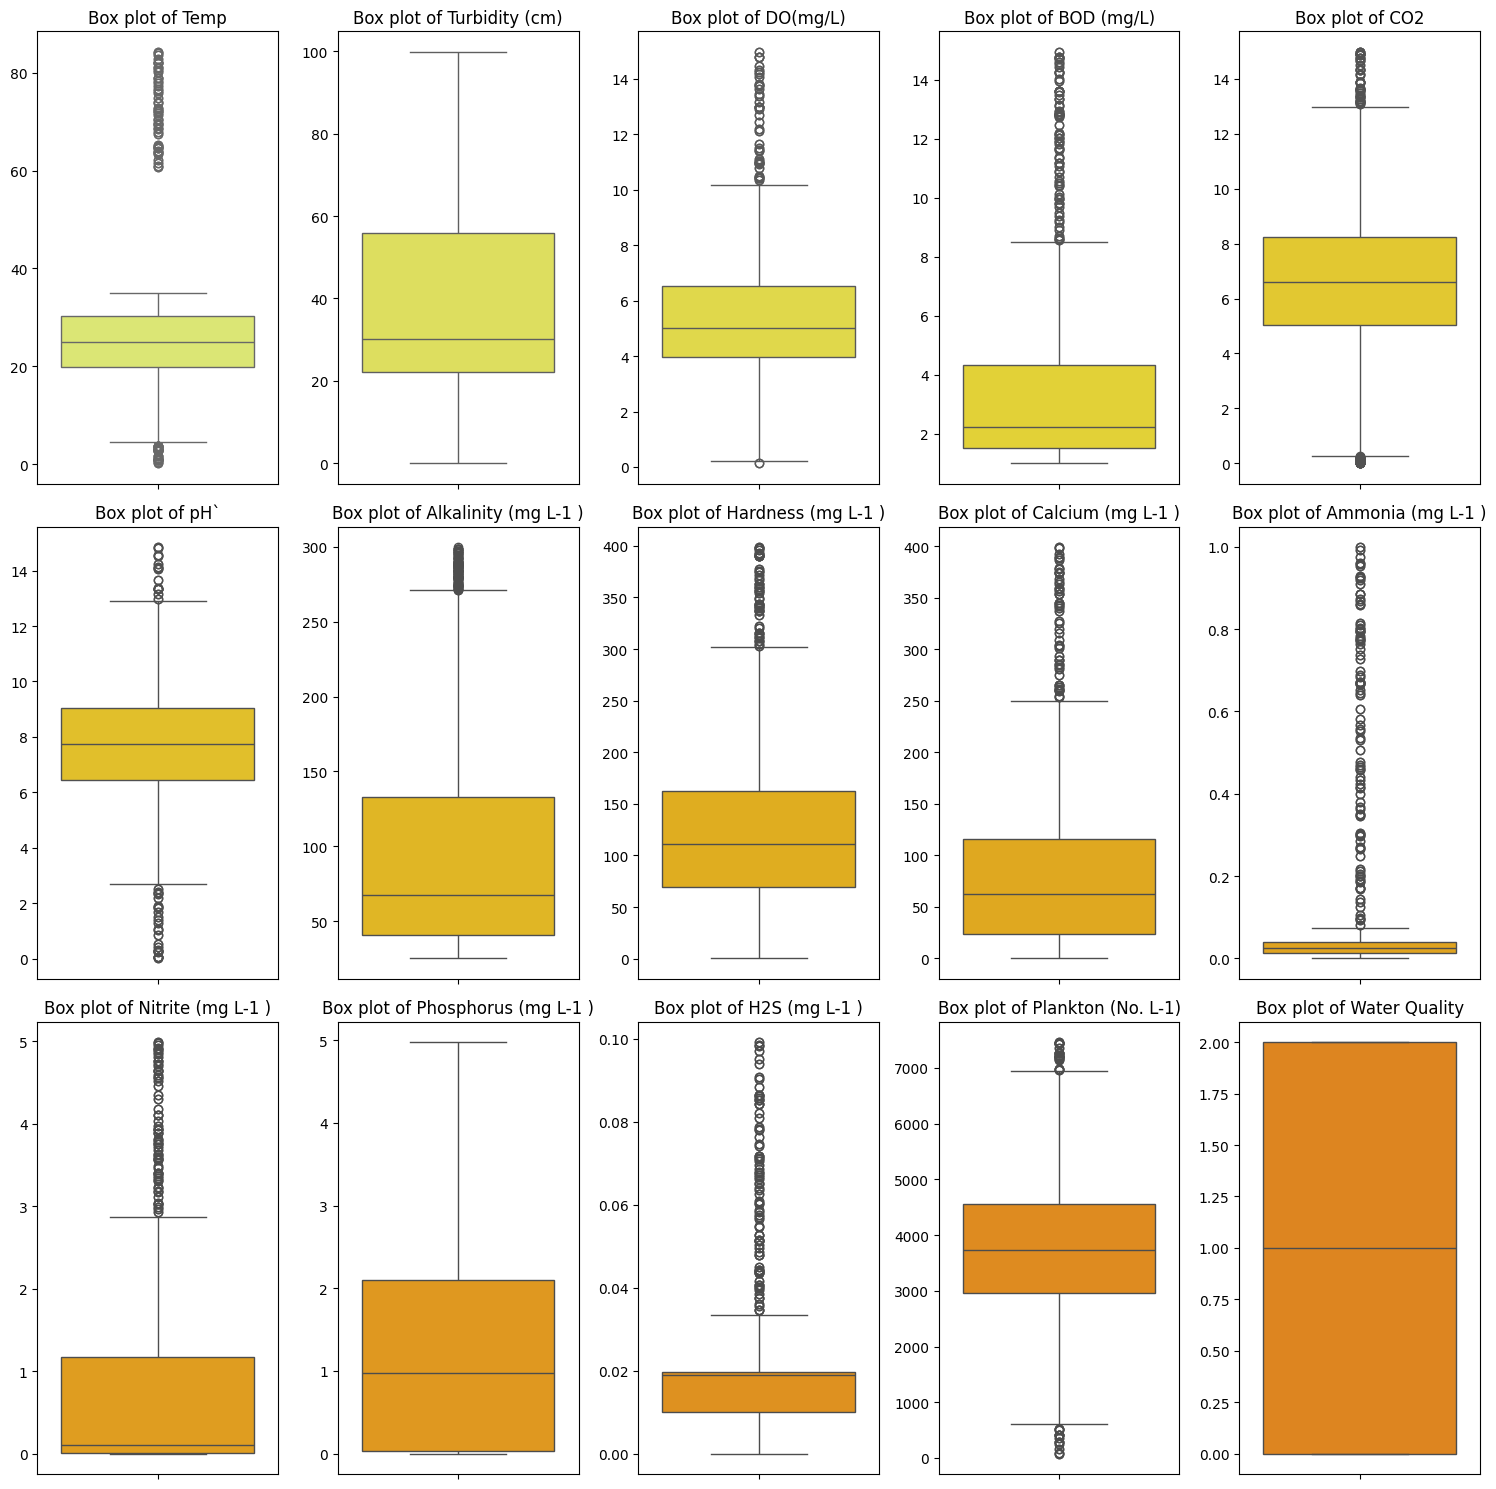

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for box plotting
numeric_cols = df.select_dtypes(include=['number']).columns

# Determine the number of rows and columns for the subplot grid
# Aim for 3 columns per row for better readability
num_cols_per_row = 5
num_rows = (len(numeric_cols) + num_cols_per_row - 1) // num_cols_per_row

plt.figure(figsize=(15, 5 * num_rows))

# Get a color palette with enough colors for all numeric columns, using 'Wistia' for brown-orange transition
colors = sns.color_palette('Wistia', n_colors=len(numeric_cols))

for i, col in enumerate(numeric_cols):
    plt.subplot(num_rows, num_cols_per_row, i + 1)
    # Assign a specific color from the palette to each box plot
    sns.boxplot(y=df[col], color=colors[i])
    plt.title(f'Box plot of {col}')
    plt.ylabel('') # Remove y-axis label to avoid clutter

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

# Assuming 'y' is already defined from df['Water Quality']
# If not, ensure it's defined: y = df['Water Quality']

# Define the mapping from numerical labels to categorical names
quality_mapping = {
    0: 'Excellent',
    1: 'Good',
    2: 'Poor'
}

y = df['Water Quality']

# Create a new Series 'y_categorical' by mapping the values
y_categorical = y.map(quality_mapping)

print("Head of the new categorical 'Water Quality' Series:")
display(y_categorical.head())

print("Value counts of the new categorical 'Water Quality' Series:")
display(y_categorical.value_counts())

Head of the new categorical 'Water Quality' Series:


,Water Quality
0,Poor
1,Poor
2,Poor
3,Poor
4,Poor


Value counts of the new categorical 'Water Quality' Series:


,count
Water Quality,
Poor,1500
Good,1400
Excellent,1400


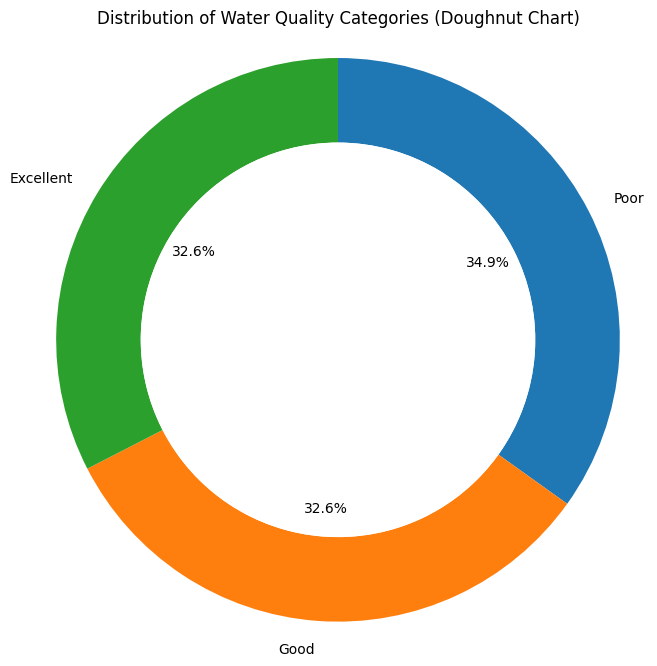

Count of each Water Quality category:


,count
Water Quality,
Poor,1500
Good,1400
Excellent,1400


In [8]:
import matplotlib.pyplot as plt

# y = df['Water Quality']

# Get the value counts for the 'Water Quality' column
water_quality_counts = y_categorical.value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(water_quality_counts, labels=water_quality_counts.index, autopct='%1.1f%%', startangle=90, counterclock=False, wedgeprops=dict(width=0.3))

# Draw a circle in the center to create the doughnut effect
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Water Quality Categories (Doughnut Chart)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

print("Count of each Water Quality category:")
display(water_quality_counts)

In [9]:
print(f"Shape of DataFrame before outlier removal: {df.shape}")

# Select only numeric columns for outlier removal
numeric_cols = df.select_dtypes(include=['number']).columns

# Remove outliers using the IQR method
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"Shape of DataFrame after outlier removal: {df.shape}")
display(df.head())

Shape of DataFrame before outlier removal: (4300, 15)
Shape of DataFrame after outlier removal: (3102, 15)


,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
111,12.257485,29.766348,6.084959,3.397404,9.214851,9.477810,40.709355,21.568500,121.935632,0.044443,1.610510,2.198595,0.013431,5509.063323,2
124,4.967443,20.963078,5.905563,2.738017,8.218755,9.436380,32.228340,197.488194,20.477560,0.034409,0.713203,2.502017,0.005873,5574.504767,2
129,9.379408,21.090956,7.544240,4.185231,1.282818,9.223327,171.144119,168.481737,21.329691,0.038211,0.175674,0.023222,0.009317,5517.948835,2
144,6.596582,26.033492,7.317996,2.859827,4.240880,9.488383,176.376358,34.511103,18.071020,0.041754,0.790023,2.741278,0.000222,2759.130360,2
148,5.859256,21.393544,6.892223,5.149949,9.698864,6.365248,128.533713,65.275700,168.468429,0.043180,1.351001,0.011600,0.008210,5998.797865,2


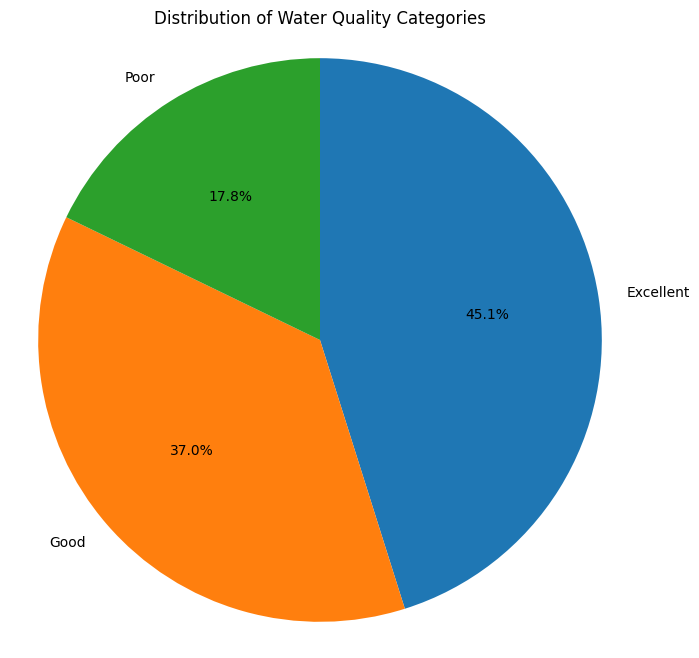

Count of each Water Quality category:


,count
Water Quality,
Excellent,1400
Good,1149
Poor,553


In [10]:
import matplotlib.pyplot as plt

y = df['Water Quality']
y_categorical = y.map(quality_mapping)

# Get the value counts for the 'Water Quality' column
water_quality_counts = y_categorical.value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(water_quality_counts, labels=water_quality_counts.index, autopct='%1.1f%%', startangle=90, counterclock=False)
plt.title('Distribution of Water Quality Categories')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

print("Count of each Water Quality category:")
display(water_quality_counts)

In [14]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

# Initialize the MinMaxScaler
# scaler = StandardScaler()
scaler = MinMaxScaler()

# Select only numeric columns for scaling, excluding 'Water Quality'
numeric_cols_to_scale = df.select_dtypes(include=['number']).columns.drop('Water Quality', errors='ignore')

# Apply Min-Max normalization to the selected numeric columns
df[numeric_cols_to_scale] = scaler.fit_transform(df[numeric_cols_to_scale])

print("DataFrame after Standard Normalization:")
display(df.head())

DataFrame after Standard Normalization:


,Temp,Turbidity (cm),DO(mg/L),BOD (mg/L),CO2,pH`,Alkalinity (mg L-1 ),Hardness (mg L-1 ),Calcium (mg L-1 ),Ammonia (mg L-1 ),Nitrite (mg L-1 ),Phosphorus (mg L-1 ),H2S (mg L-1 ),Plankton (No. L-1),Water Quality
111,0.253294,0.297905,0.581159,0.340908,0.718852,0.665793,0.069630,0.073492,0.548007,0.681658,0.655846,0.462524,0.411975,0.815591,2
124,0.013854,0.209648,0.562749,0.247120,0.637618,0.661653,0.032009,0.693182,0.090533,0.527757,0.290431,0.526359,0.180091,0.827376,2
129,0.158764,0.210930,0.730914,0.452965,0.071969,0.640363,0.648225,0.591005,0.094375,0.586069,0.071530,0.004859,0.285773,0.817191,2
144,0.067363,0.260481,0.707696,0.264445,0.313208,0.666849,0.671435,0.119083,0.079682,0.640405,0.321715,0.576696,0.006744,0.320399,2
148,0.043146,0.213964,0.664002,0.590182,0.758325,0.354769,0.459210,0.227454,0.757823,0.662287,0.550165,0.002413,0.251804,0.903780,2


In [15]:
from sklearn.model_selection import train_test_split

X = df.drop('Water Quality', axis=1)
# y = df['Water Quality']

X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, stratify=y, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2481, 14)
Shape of X_test: (621, 14)
Shape of y_train: (2481,)
Shape of y_test: (621,)



--- Training Linear Discriminant Analysis (LDA) ---

LDA Classification Report:
              precision    recall  f1-score   support

   Excellent     0.8805    1.0000    0.9365       280
        Good     0.8814    0.9696    0.9234       230
        Poor     0.8600    0.3874    0.5342       111

    accuracy                         0.8792       621
   macro avg     0.8740    0.7857    0.7980       621
weighted avg     0.8772    0.8792    0.8597       621


LDA Confusion Matrix:


,Excellent,Good,Poor
Excellent,280,0,0
Good,0,223,7
Poor,38,30,43


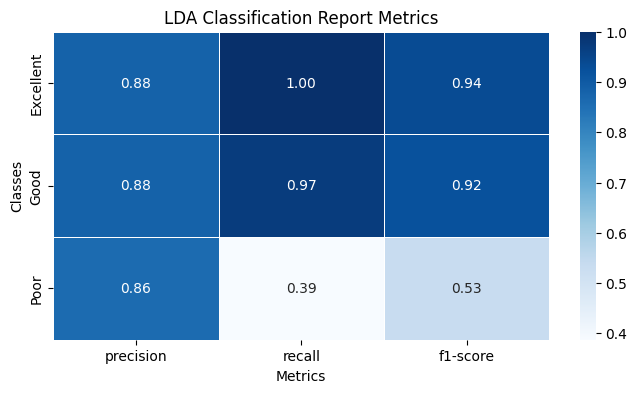


--- Training Quadratic Discriminant Analysis (QDA) ---

QDA Classification Report:
              precision    recall  f1-score   support

   Excellent     0.9241    1.0000    0.9605       280
        Good     0.9237    1.0000    0.9603       230
        Poor     1.0000    0.6216    0.7667       111

    accuracy                         0.9324       621
   macro avg     0.9493    0.8739    0.8958       621
weighted avg     0.9375    0.9324    0.9258       621


QDA Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


,Excellent,Good,Poor
Excellent,280,0,0
Good,0,230,0
Poor,23,19,69


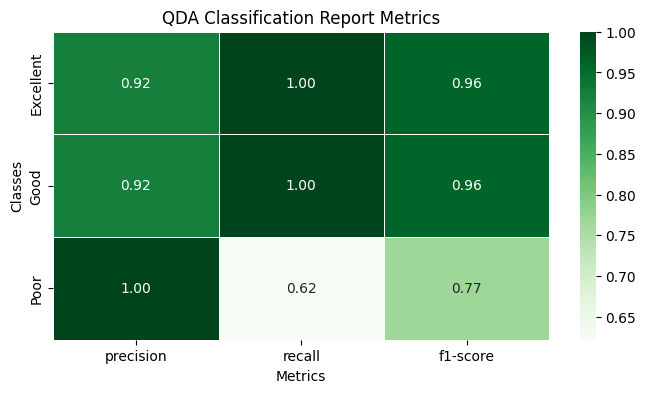

In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get unique class names for confusion matrix labels
class_names = np.unique(y_test)

# Initialize LDA and QDA models
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis(tol=0.00001)

# Train LDA model
print("\n--- Training Linear Discriminant Analysis (LDA) ---")
lda.fit(X_train, y_train)

# Predict with LDA
y_pred_lda = lda.predict(X_test)

# Evaluate LDA
print("\nLDA Classification Report:")
report_lda = classification_report(y_test, y_pred_lda, digits=4, output_dict=True)
print(classification_report(y_test, y_pred_lda, digits=4))
print("\nLDA Confusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_lda), index=class_names, columns=class_names))

# Visualize LDA Classification Report
report_df_lda = pd.DataFrame(report_lda).transpose().iloc[:-3, :3] # Exclude accuracy, macro avg, weighted avg, and support
plt.figure(figsize=(8, 4))
sns.heatmap(report_df_lda, annot=True, cmap='Blues', fmt='.2f', linewidths=.5)
plt.title('LDA Classification Report Metrics')
plt.xlabel('Metrics')
plt.ylabel('Classes')
plt.show()

# Train QDA model
print("\n--- Training Quadratic Discriminant Analysis (QDA) ---")
qda.fit(X_train, y_train)

# Predict with QDA
y_pred_qda = qda.predict(X_test)

# Evaluate QDA
print("\nQDA Classification Report:")
report_qda = classification_report(y_test, y_pred_qda, digits=4, output_dict=True)
print(classification_report(y_test, y_pred_qda, digits=4))
print("\nQDA Confusion Matrix:")
display(pd.DataFrame(confusion_matrix(y_test, y_pred_qda), index=class_names, columns=class_names))

# Visualize QDA Classification Report
report_df_qda = pd.DataFrame(report_qda).transpose().iloc[:-3, :3] # Exclude accuracy, macro avg, weighted avg, and support
plt.figure(figsize=(8, 4))
sns.heatmap(report_df_qda, annot=True, cmap='Greens', fmt='.2f', linewidths=.5)
plt.title('QDA Classification Report Metrics')
plt.xlabel('Metrics')
plt.ylabel('Classes')
plt.show()

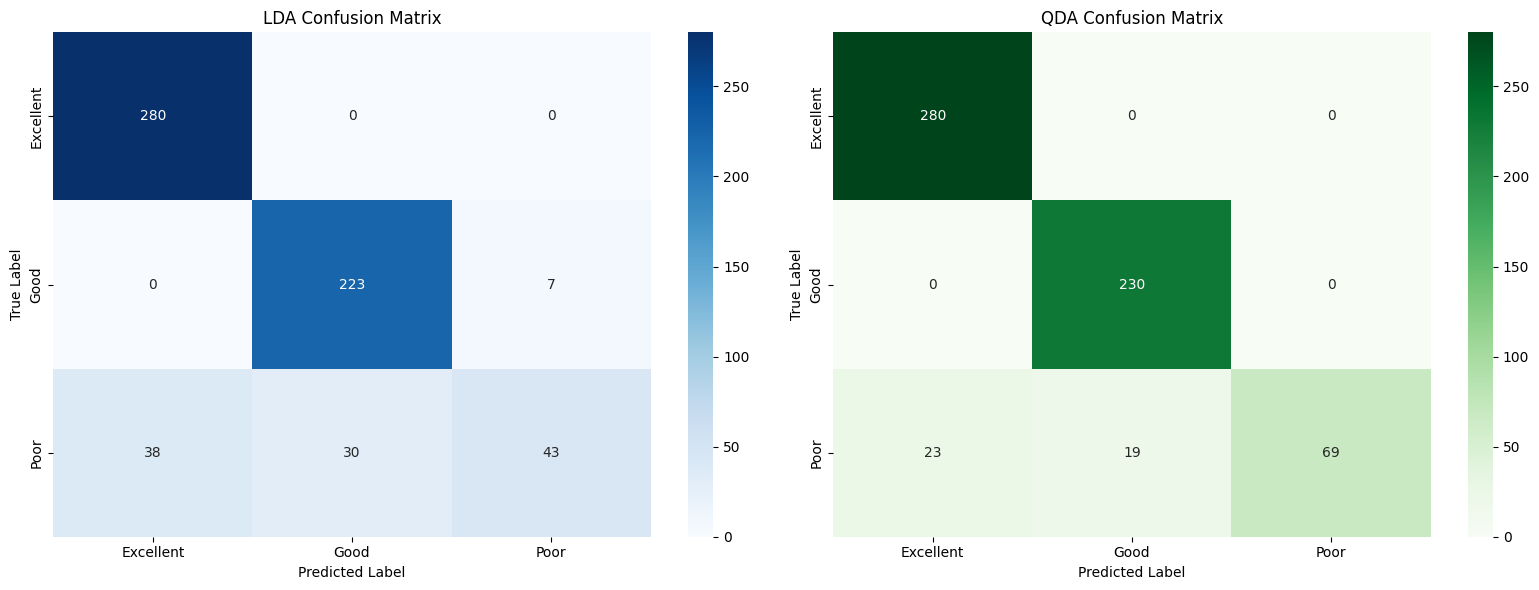

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Get class names for labeling
class_names = np.unique(y_test)

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LDA Confusion Matrix
cm_lda = confusion_matrix(y_test, y_pred_lda)
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=class_names, yticklabels=class_names)
ax1.set_title('LDA Confusion Matrix')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

# QDA Confusion Matrix
cm_qda = confusion_matrix(y_test, y_pred_qda)
sns.heatmap(cm_qda, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=class_names, yticklabels=class_names)
ax2.set_title('QDA Confusion Matrix')
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')

plt.tight_layout()
plt.show()

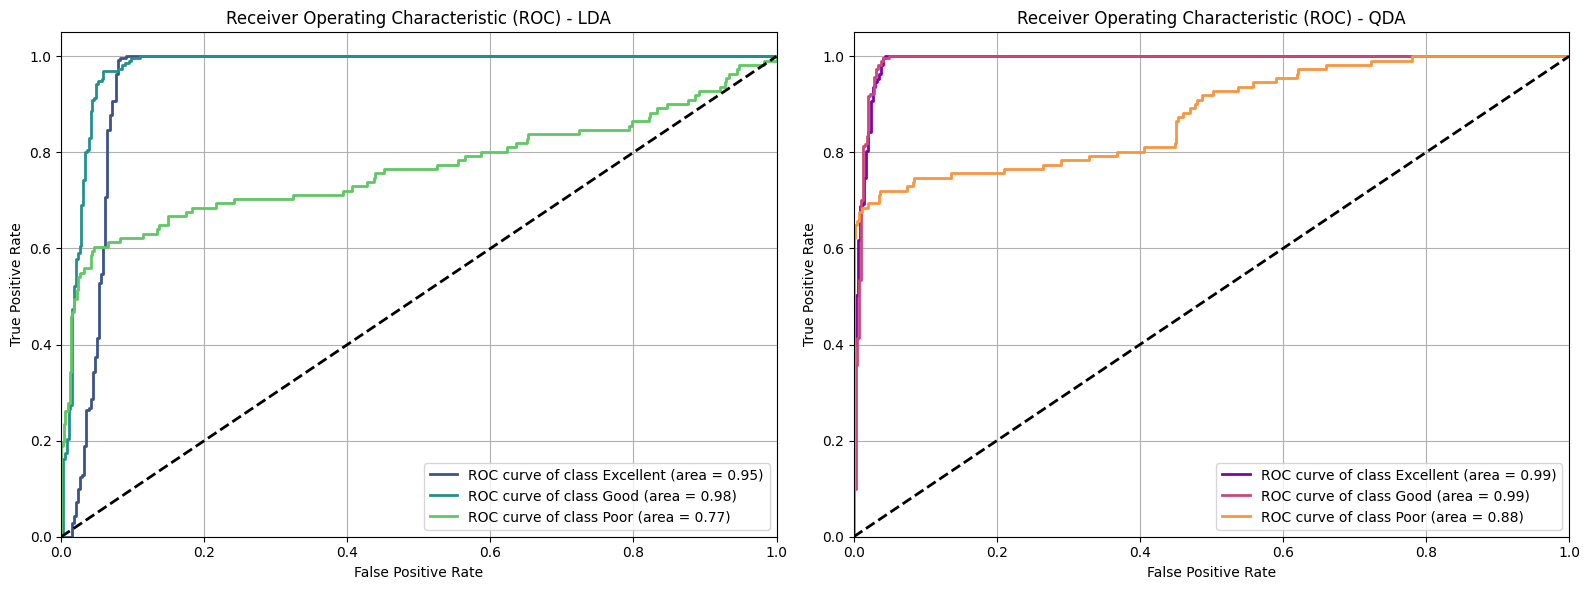

In [17]:
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Initialize LabelBinarizer for one-hot encoding multi-class labels
label_binarizer = LabelBinarizer()
y_test_binarized = label_binarizer.fit_transform(y_test)
class_names_ordered = label_binarizer.classes_

plt.figure(figsize=(16, 6))

# --- LDA ROC AUC ---

# Get probability predictions for LDA
y_proba_lda = lda.predict_proba(X_test)

plt.subplot(1, 2, 1)
colors = sns.color_palette('viridis', n_colors=len(class_names_ordered))

for i, class_id in enumerate(class_names_ordered):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_proba_lda[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'ROC curve of class {class_id} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - LDA')
plt.legend(loc='lower right')
plt.grid(True)

# --- QDA ROC AUC ---

# Get probability predictions for QDA
y_proba_qda = qda.predict_proba(X_test)

plt.subplot(1, 2, 2)
colors = sns.color_palette('plasma', n_colors=len(class_names_ordered))

for i, class_id in enumerate(class_names_ordered):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_proba_qda[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'ROC curve of class {class_id} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - QDA')
plt.legend(loc='lower right')
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd

print("\n--- LDA Weighted Average Evaluation Metrics ---")
display(pd.DataFrame([report_lda['weighted avg']]))

print("\n--- QDA Weighted Average Evaluation Metrics ---")
display(pd.DataFrame([report_qda['weighted avg']]))


--- LDA Weighted Average Evaluation Metrics ---


,precision,recall,f1-score,support
0,0.877179,0.879227,0.859711,621.0



--- QDA Weighted Average Evaluation Metrics ---


,precision,recall,f1-score,support
0,0.937513,0.932367,0.925814,621.0


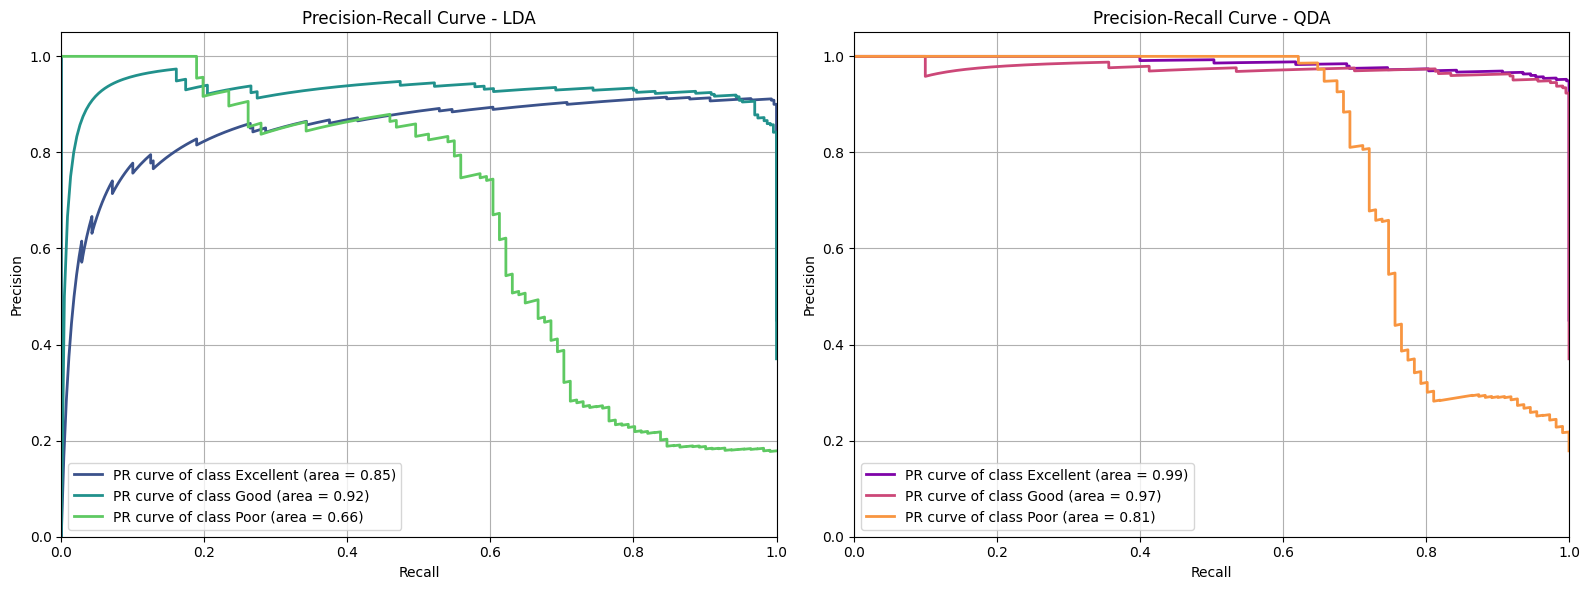

In [20]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming y_test_binarized, y_proba_lda, y_proba_qda, and class_names_ordered are available from previous cells

plt.figure(figsize=(16, 6))

# --- LDA Precision-Recall Curve ---
plt.subplot(1, 2, 1)
colors_lda = sns.color_palette('viridis', n_colors=len(class_names_ordered))

for i, class_id in enumerate(class_names_ordered):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_proba_lda[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color=colors_lda[i], lw=2, label=f'PR curve of class {class_id} (area = {pr_auc:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - LDA')
plt.legend(loc='lower left')
plt.grid(True)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# --- QDA Precision-Recall Curve ---
plt.subplot(1, 2, 2)
colors_qda = sns.color_palette('plasma', n_colors=len(class_names_ordered))

for i, class_id in enumerate(class_names_ordered):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_proba_qda[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, color=colors_qda[i], lw=2, label=f'PR curve of class {class_id} (area = {pr_auc:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - QDA')
plt.legend(loc='lower left')
plt.grid(True)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.tight_layout()
plt.show()

In [26]:
lda_weighted_avg_df = pd.DataFrame([report_lda['weighted avg']])
lda_weighted_avg_df.index = ['LDA']

qda_weighted_avg_df = pd.DataFrame([report_qda['weighted avg']])
qda_weighted_avg_df.index = ['QDA']

# Concatenate the two DataFrames
combined_metrics_df = pd.concat([lda_weighted_avg_df, qda_weighted_avg_df])

# Rename the index
combined_metrics_df.index.name = 'Model'

print("Combined Weighted Average Evaluation Metrics for LDA and QDA:")
display(combined_metrics_df)

Combined Weighted Average Evaluation Metrics for LDA and QDA:


,precision,recall,f1-score,support
Model,,,,
LDA,0.877179,0.879227,0.859711,621.0
QDA,0.937513,0.932367,0.925814,621.0


In [35]:
lda_metrics = report_lda['weighted avg'].copy()
lda_metrics['accuracy'] = report_lda['accuracy']

qda_metrics = report_qda['weighted avg'].copy()
qda_metrics['accuracy'] = report_qda['accuracy']

lda_weighted_avg_df = pd.DataFrame([lda_metrics])
lda_weighted_avg_df.index = ['LDA']

qda_weighted_avg_df = pd.DataFrame([qda_metrics])
qda_weighted_avg_df.index = ['QDA']

# Concatenate the two DataFrames
combined_metrics_df = pd.concat([lda_weighted_avg_df, qda_weighted_avg_df])

# Rename the index
combined_metrics_df.index.name = 'Model'

print("Combined Weighted Average Evaluation Metrics for LDA and QDA:")
display(combined_metrics_df)

Combined Weighted Average Evaluation Metrics for LDA and QDA:


,precision,recall,f1-score,support,accuracy
Model,,,,,
LDA,0.877179,0.879227,0.859711,621.0,0.879227
QDA,0.937513,0.932367,0.925814,621.0,0.932367


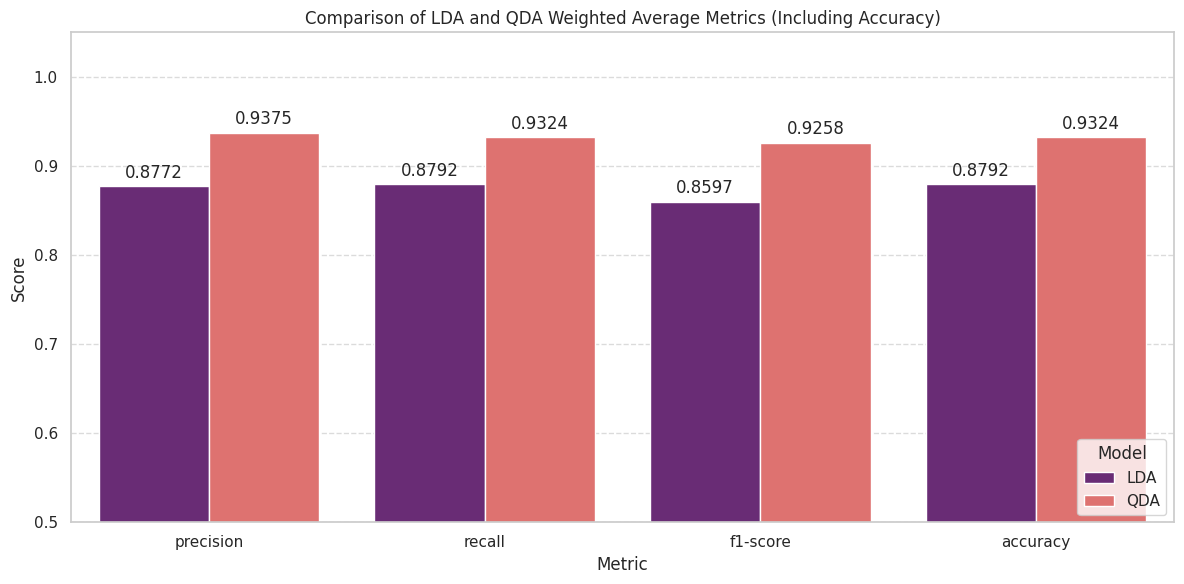

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting including accuracy (dropping only support)
plot_df = combined_metrics_df.drop(columns=['support'])
plot_df_melted = plot_df.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df_melted, x='Metric', y='Score', hue='Model', palette='magma')

# Add values on top of the bars
for container in plt.gca().containers:
    for p in container:
        height = p.get_height()
        plt.gca().text(p.get_x() + p.get_width() / 2., height + 0.005,
                       f'{height:.4f}', ha="center", va='bottom')

plt.title('Comparison of LDA and QDA Weighted Average Metrics (Including Accuracy)')
plt.xlabel('Metric')
plt.ylabel('Score')
plt.ylim(0.5, 1.05)
plt.legend(title='Model', loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()